# Contour

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [6]:
image = cv2.imread('image.png')

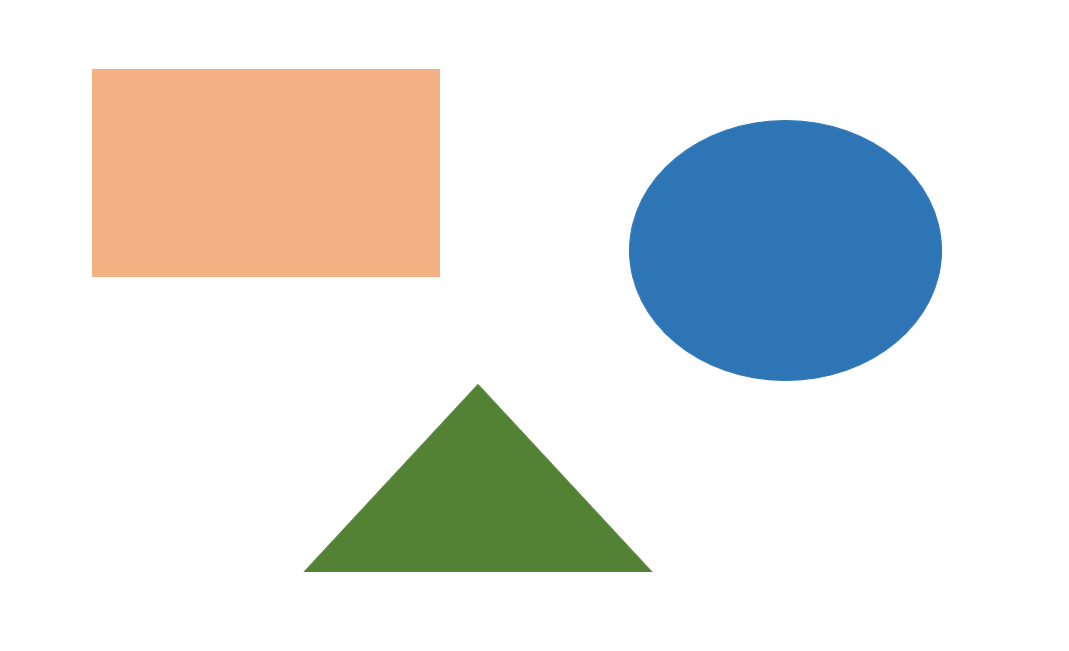

In [7]:
cv2_imshow(image)

# 1. Convert to Grayscale

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

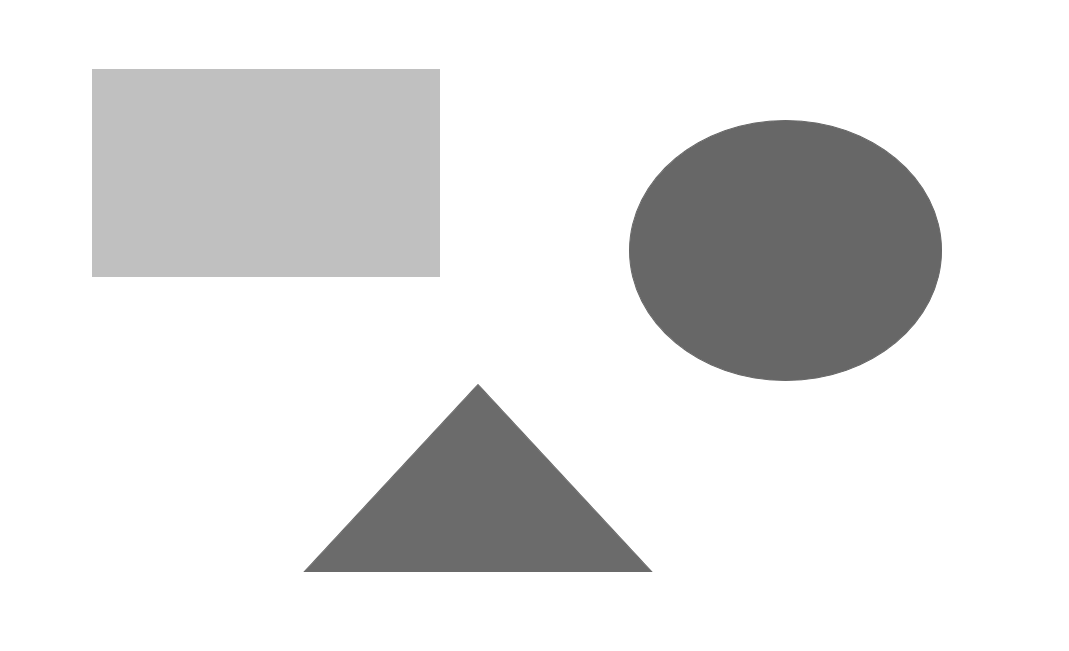

In [9]:
cv2_imshow(gray)

# 2. Apply Thresholding


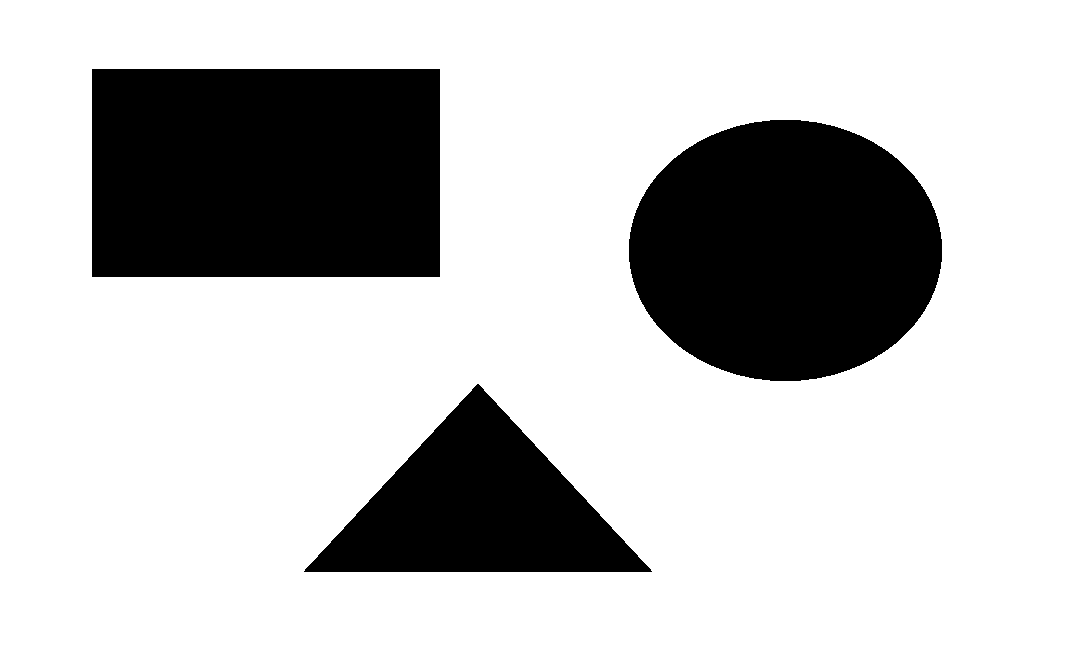

In [10]:
_, threshold = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
cv2_imshow(threshold)

# 2. Edge Detection using Canny Function

In [11]:
edged = cv2.Canny(threshold, 30, 200)

# 3. Find Contoures

In [12]:
contours, hierarchy = cv2.findContours(edged,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 4. Visualize contour

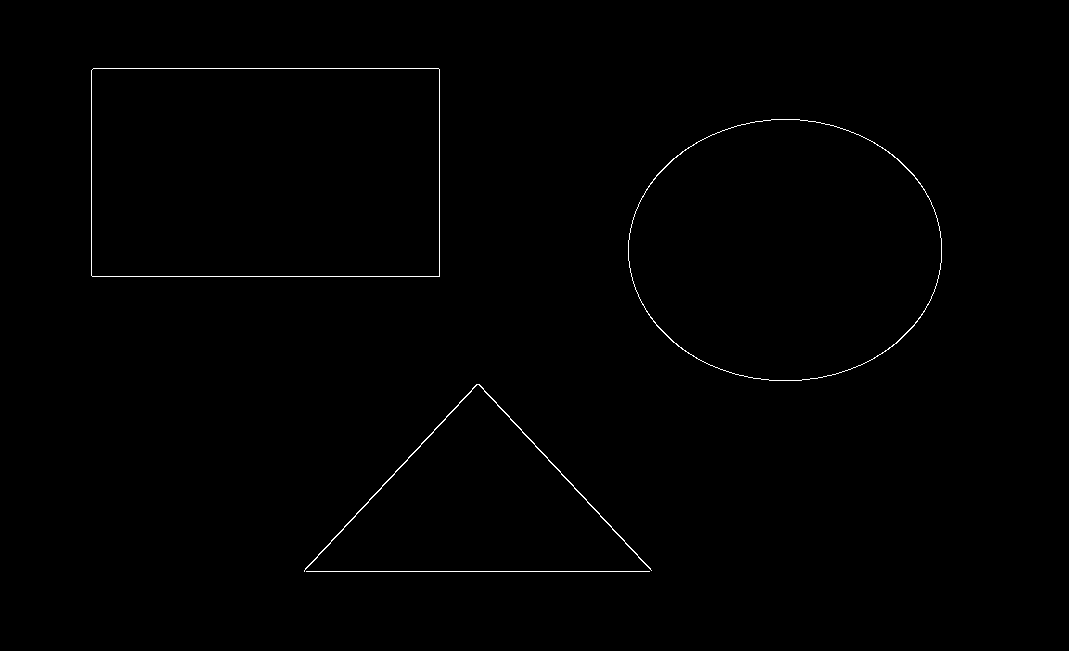

In [13]:
cv2_imshow(edged)

# 5. find contour Length

In [14]:
print("Number of Contours Found = " + str(len(contours)))

Number of Contours Found = 4


# 6. Draw Contour on the Real Image

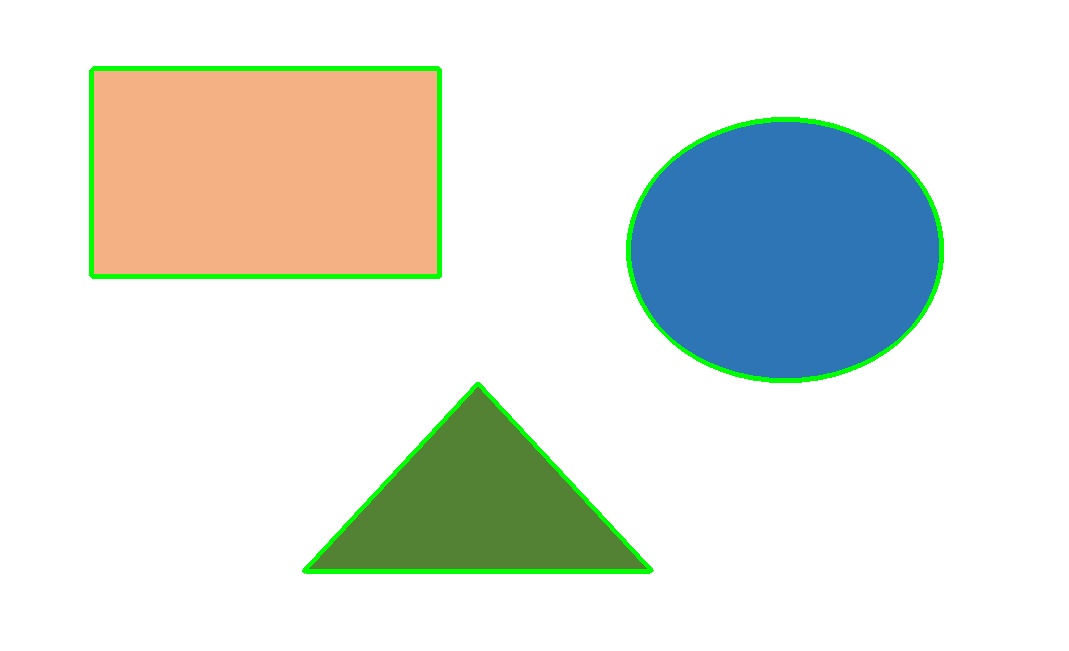

In [15]:
cv2.drawContours(image, contours, -1, (0, 255, 0), 3)
cv2_imshow(image)

# 7. Calculate Area and Perimeter of each contour


In [16]:
for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    print(f"Contour {i+1}")
    print(f"Area      : {area:.2f}")
    print(f"Perimeter : {perimeter:.2f}")

Contour 1
Area      : 0.00
Perimeter : 686.00
Contour 2
Area      : 317.00
Perimeter : 1035.81
Contour 3
Area      : 64292.00
Perimeter : 953.52
Contour 4
Area      : 72381.00
Perimeter : 1109.66


# Shape Detection

In [17]:
result = image.copy()

Area: 317.00
Perimeter: 1035.81
Vertices: 3
Area: 64292.00
Perimeter: 953.52
Vertices: 8
Area: 72381.00
Perimeter: 1109.66
Vertices: 4


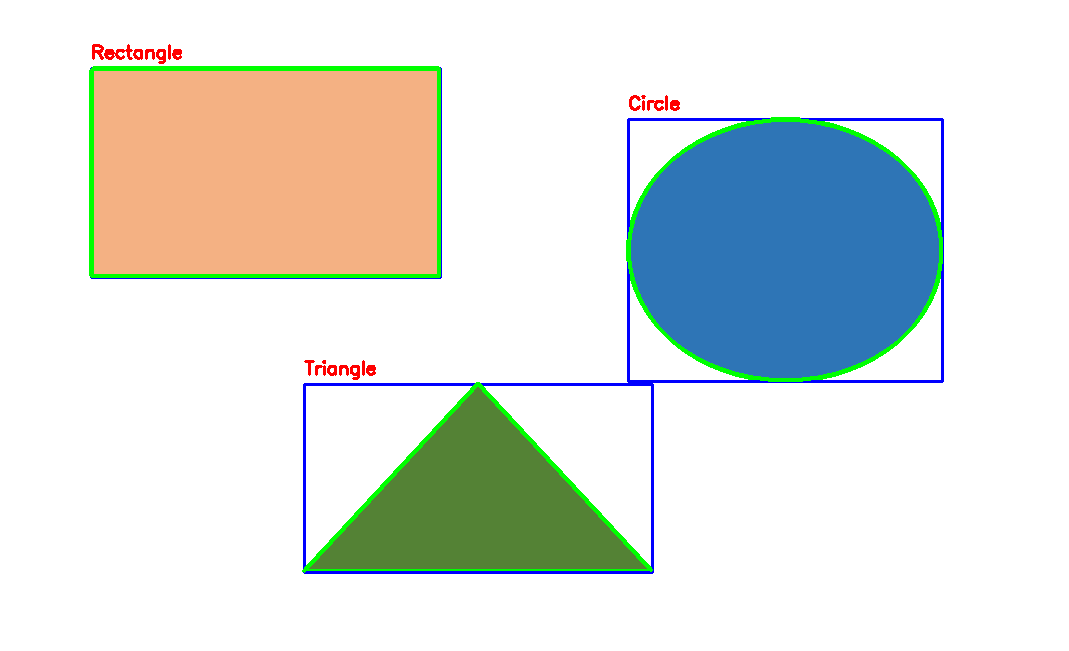

In [19]:
# Loop through each contour
for contour in contours:

    # Ignore very small contours (noise)
    if cv2.contourArea(contour) < 100:
        continue

    # Calculate area and perimeter
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    print(f"Area: {area:.2f}")
    print(f"Perimeter: {perimeter:.2f}")

    # Draw Bounding Rectangle
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(result, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Approximate the contour
    hull = cv2.convexHull(contour)
    approx = cv2.approxPolyDP(hull, 0.02 * cv2.arcLength(hull, True), True)

    print("Vertices:", len(approx))

    # Detect Shape
    sides = len(approx)

    if sides == 3:
        shape = "Triangle"

    elif sides == 4:
        aspect_ratio = w / float(h)
        if 0.95 <= aspect_ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    elif sides == 5:
        shape = "Pentagon"

    elif sides == 6:
        shape = "Hexagon"

    else:
        shape = "Circle"

    # Draw contour
    cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)

    # Write shape name
    cv2.putText(
        result,
        shape,
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

# Display Final Result
cv2_imshow(result)